# 📀 De lo Físico a lo Digital: La Transformación de la Industria Musical en EE.UU.

Este notebook analiza la evolución de los ingresos de la industria musical estadounidense entre **1973 y 2019**, comparando el formato **físico** (CDs, vinilos, casetes) contra el **digital** (descargas, streaming).

**Objetivo:** visualizar cómo el lanzamiento de la *iTunes Music Store* en 2003 marcó el punto de inflexión que aceleró el declive del formato físico y dio inicio a la era digital.

---
## 1. Carga y limpieza de datos

Los datos originales vienen en formato moneda (ej. `"$11,612"`), por lo que es necesario:
1. Eliminar el símbolo `$`
2. Eliminar las comas de separador de miles
3. Convertir el resultado a tipo `float`


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Ruta del archivo de datos
DATA_PATH = "data/raw/US_Music_Revenues.csv"

# Cargar el dataset
df = pd.read_csv(DATA_PATH)

# Vista previa antes de limpiar
df.head()


,Year,Physical,Digital
0,1973,"$11,612",$0
1,1974,"$11,407",$0
2,1975,"$11,350",$0
3,1976,"$12,298",$0
4,1977,"$14,769",$0


In [ ]:
def limpiar_moneda(columna: pd.Series) -> pd.Series:
    """Convierte una columna con formato moneda ($, comas) a tipo float."""
    return (
        columna.astype(str)
        .str.replace(r"[\$,]", "", regex=True)
        .astype(float)
    )

# Limpiar columnas Physical y Digital
df["Physical"] = limpiar_moneda(df["Physical"])
df["Digital"] = limpiar_moneda(df["Digital"])
df["Year"] = df["Year"].astype(int)

# Ordenar por año (por seguridad) y verificar tipos
df = df.sort_values("Year").reset_index(drop=True)
print(df.dtypes)
df.head()


Year          int64
Physical    float64
Digital     float64
dtype: object


,Year,Physical,Digital
0,1973,11612.0,0.0
1,1974,11407.0,0.0
2,1975,11350.0,0.0
3,1976,12298.0,0.0
4,1977,14769.0,0.0


## 2. Ingresos totales y participación digital

Antes de graficar, calculamos el ingreso total y el porcentaje que representa el mercado digital en cada año. Esto nos ayudará a ubicar el momento exacto del cruce entre ambos formatos.


In [ ]:
df["Total"] = df["Physical"] + df["Digital"]
df["Digital_pct"] = (df["Digital"] / df["Total"]).fillna(0) * 100

# Año en que el digital supera al físico (si ya ocurrió dentro del rango de datos)
cruce = df[df["Digital"] > df["Physical"]]
anio_cruce = cruce["Year"].iloc[0] if not cruce.empty else None
print(f"Año en que el ingreso digital supera al físico: {anio_cruce}")


Año en que el ingreso digital supera al físico: 2011


## 3. Visualización: evolución del mercado físico vs. digital

Usamos un **gráfico de área apilada** para mostrar simultáneamente:
- La composición del ingreso total (físico + digital) en cada año.
- La tendencia general del mercado musical.

Se destaca **2003**, año de lanzamiento de la *iTunes Music Store*, considerado el punto de inflexión que impulsó la adopción masiva de la música digital y aceleró la caída del formato físico.

### Principios de diseño aplicados
- Paleta de colores profesional y con buen contraste (azul apagado para físico, coral/naranja para digital).
- Eliminación de bordes y ruido visual innecesario (`sns.despine`).
- Anotación clara y contextual en 2003, sin saturar el gráfico.
- Ejes con formato legible (años enteros, ingresos en millones de USD).


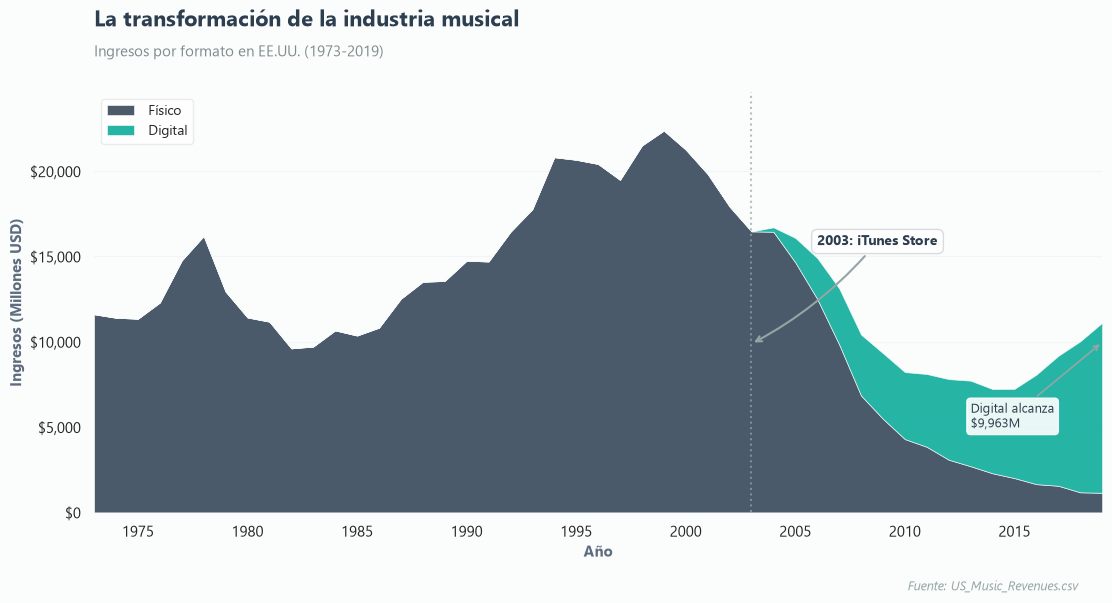

In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.patches import Rectangle

# Configuración profesional pero sobria
sns.set_theme(style="white")
plt.rcParams.update({
    'figure.dpi': 100,
    'font.family': 'Segoe UI',
    'font.size': 10
})

# Paleta de colores mejorada (más moderna)
COLORS = {
    'physical': '#2C3E50',      # Azul grisáceo oscuro
    'digital': '#00A896',       # Verde turquesa
    'bg': '#FBFCFC',
    'grid': '#ECF0F1',
    'text': '#2C3E50'
}

# Crear figura
fig, ax = plt.subplots(figsize=(12, 6), facecolor=COLORS['bg'])
ax.set_facecolor(COLORS['bg'])

# --- 1. ÁREA APILADA CON BORDES MÁS SUAVES ---
ax.stackplot(
    df["Year"],
    df["Physical"],
    df["Digital"],
    labels=["Físico", "Digital"],
    colors=[COLORS['physical'], COLORS['digital']],
    alpha=0.85,
    edgecolor=COLORS['bg'],
    linewidth=0.5
)

# --- 2. LÍNEA DE TOTAL (OPCIONAL, SUTIL) ---
# ax.plot(df["Year"], df["Total"], color='#E74C3C', linewidth=1.5, 
#         alpha=0.4, label='Total', linestyle='--')

# --- 3. LÍNEA VERTICAL MÁS LIMPIA ---
ax.axvline(x=2003, color='#95A5A6', linestyle=':', linewidth=1.5, alpha=0.7)

# --- 4. ANOTACIÓN MEJORADA (MÁS LIMPIA) ---
ymax = df["Total"].max()
ax.annotate(
    "2003: iTunes Store",
    xy=(2003, df.loc[df["Year"]==2003, "Total"].values[0] * 0.6),
    xytext=(2006, ymax * 0.7),
    fontsize=10,
    fontweight='bold',
    color=COLORS['text'],
    arrowprops=dict(
        arrowstyle='->',
        color='#95A5A6',
        lw=1.5,
        connectionstyle='arc3,rad=-0.1'
    ),
    bbox=dict(
        boxstyle='round,pad=0.4',
        facecolor='white',
        edgecolor='#D5D8DC',
        alpha=0.9
    )
)

# Agregar una segunda anotación relevante (opcional, solo si hay datos)
# Si tienes el punto máximo de digital, puedes añadirlo
digital_peak = df.loc[df["Digital"].idxmax()]
if digital_peak["Year"] >= 2010:
    ax.annotate(
        f"Digital alcanza\n${digital_peak['Digital']:,.0f}M",
        xy=(digital_peak["Year"], digital_peak["Digital"]),
        xytext=(digital_peak["Year"]-6, digital_peak["Digital"]*0.5),
        fontsize=9,
        color=COLORS['text'],
        arrowprops=dict(arrowstyle='->', color='#95A5A6', lw=1.2),
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9)
    )

# --- 5. TÍTULOS Y ETIQUETAS (MÁS CLAROS) ---
fig.text(0.08, 0.96, "La transformación de la industria musical", 
         fontsize=16, fontweight='bold', color=COLORS['text'])
fig.text(0.08, 0.91, "Ingresos por formato en EE.UU. (1973-2019)", 
         fontsize=11, color='#7F8C8D')

ax.set_xlabel("Año", fontsize=11, fontweight='bold', color='#5D6D7E')
ax.set_ylabel("Ingresos (Millones USD)", fontsize=11, fontweight='bold', color='#5D6D7E')

# --- 6. FORMATO DE EJES MEJORADO ---
ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

ax.set_xlim(df["Year"].min(), df["Year"].max())
ax.set_ylim(0, ymax * 1.1)

# --- 7. GRID MÁS LIMPIA ---
ax.grid(axis='y', color=COLORS['grid'], linestyle='-', alpha=0.6, linewidth=0.8)
ax.grid(axis='x', visible=False)

# --- 8. LEGENDA MEJORADA ---
legend = ax.legend(
    loc='upper left',
    frameon=True,
    facecolor='white',
    edgecolor='#E5E8E8',
    fontsize=10,
    handletextpad=1
)

# --- 9. ELIMINAR BORDES INNECESARIOS ---
sns.despine(left=True, bottom=True, top=True, right=True)

# --- 10. FOOTER ---
fig.text(0.90, 0.02, "Fuente: US_Music_Revenues.csv", 
         ha='right', fontsize=9, color='#95A5A6', style='italic')

# Ajustes finales
plt.subplots_adjust(top=0.85, bottom=0.15, left=0.08, right=0.92)

plt.savefig("music_industry_clean.png", dpi=300, bbox_inches="tight", 
            facecolor=fig.get_facecolor())
plt.show()

## 4. Conclusiones

- Durante las décadas de 1970 a 1990, el ingreso de la industria musical en EE.UU. dependía casi por completo del formato **físico**.
- A partir de **2003**, con el lanzamiento de la *iTunes Music Store*, comienza a registrarse ingreso **digital** por primera vez, iniciando una tendencia sostenida de crecimiento.
- El ingreso físico entra en una caída consistente año tras año desde ese punto, mientras que el digital lo compensa gradualmente hasta superarlo.
- Este gráfico ilustra visualmente cómo un solo evento tecnológico (la aparición de una tienda digital legal y masiva) puede transformar por completo la estructura de una industria en poco más de una década.

El archivo `music_industry_physical_vs_digital.png` contiene la versión en alta resolución (300 DPI) de este gráfico, lista para presentaciones o reportes.
